# Hyperparameter Search Results — PLR `score_temp`

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

results = json.load(open("../results/temperature.json"))
df = pd.DataFrame(results).rename(columns={
    "env.plr.score_temp": "score_temp",
    "metric": "eval_iqm",
})
df = df.sort_values("score_temp").reset_index(drop=True)
df[["trial", "seed", "score_temp", "eval_iqm"]]

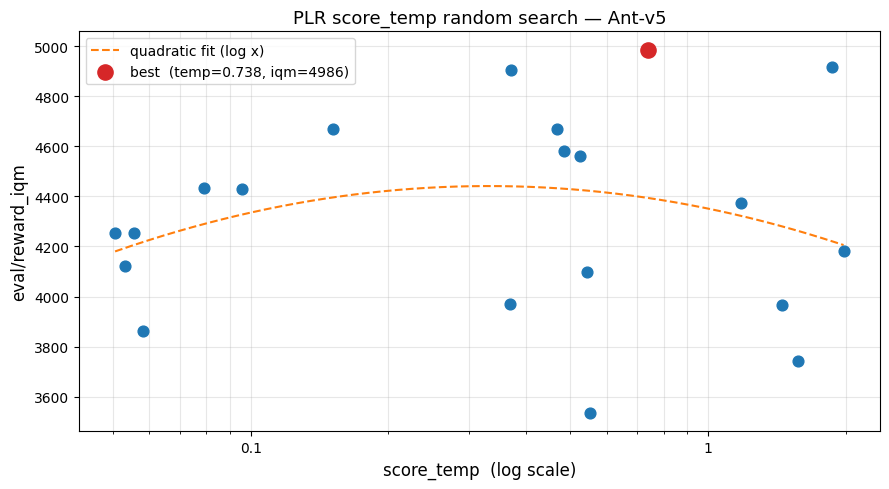


Best:  score_temp=0.7378  eval_iqm=4986.0  (trial 9, seed 33585)


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(df["score_temp"], df["eval_iqm"], s=60, zorder=3)

# Trend line (log-space x since we sampled log-uniformly)
log_x = np.log(df["score_temp"])
coeffs = np.polyfit(log_x, df["eval_iqm"], deg=2)
x_smooth = np.exp(np.linspace(log_x.min(), log_x.max(), 300))
ax.plot(x_smooth, np.polyval(coeffs, np.log(x_smooth)),
        color="tab:orange", linewidth=1.5, linestyle="--", label="quadratic fit (log x)")

# Mark best trial
best = df.loc[df["eval_iqm"].idxmax()]
ax.scatter(best["score_temp"], best["eval_iqm"],
           s=120, color="tab:red", zorder=4, label=f"best  (temp={best['score_temp']:.3f}, iqm={best['eval_iqm']:.0f})")

ax.set_xscale("log")
ax.set_xlabel("score_temp  (log scale)", fontsize=12)
ax.set_ylabel("eval/reward_iqm", fontsize=12)
ax.set_title("PLR score_temp random search — Ant-v5", fontsize=13)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3g"))
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest:  score_temp={best['score_temp']:.4f}  eval_iqm={best['eval_iqm']:.1f}  (trial {int(best['trial'])}, seed {int(best['seed'])})")